# 01 - Data Preparation and Offline Baseline
This notebooke prepares the time-series data used in the project and builds the offline baseline controller.

Project Goal:
- forcast future traffic demand from historical demand
- use predicted demand to select a network operating mode
- evaluate the throughput-energy tradeoff

In this particular notebook, the focus is on the **static baseline**:
- offline-trained predictor
- fixed decision thresholds
- no online adaption (yet)

## Section 1 - Imports and config

This section imports the required libs and defines the basic experiment setting:
- selected grid cell
- train/test split
- prediction window length
- output paths

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [158]:
# Display settings
# Make notebook tables and plots easier to read
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [159]:
# -----------------------------
# Paths
# -----------------------------
processed_path = Path("../data/processed/internet_by_grid_time.parquet")

output_dir = Path("../outputs")
fig_dir = output_dir / "figures"
metrics_dir = output_dir / "metrics"
tables_dir = output_dir / "tables"

fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Data selection
# -----------------------------
GRID_ID = 5161

# -----------------------------
# Forecasting setup
# -----------------------------
WINDOW_SIZE = 12      # 12 * 10 minutes = 2 hours of history
TRAIN_RATIO = 0.7     # 70% train, 30% test

# -----------------------------
# Fixed-threshold setup
# -----------------------------
LOW_PERCENTILE = 30
HIGH_PERCENTILE = 60

In [160]:
# print out the settings for reference
print("Processed parquet path:", processed_path)
print("Selected Grid ID:", GRID_ID)
print("Window size:", WINDOW_SIZE, "steps")
print("Train ratio:", TRAIN_RATIO)
print("Threshold percentiles:", (LOW_PERCENTILE, HIGH_PERCENTILE))

Processed parquet path: ../data/processed/internet_by_grid_time.parquet
Selected Grid ID: 5161
Window size: 12 steps
Train ratio: 0.7
Threshold percentiles: (30, 60)


## Section 2 - Load precessed time series

The raw telecom dataset was already aggregated and saved as a processed parquet file in the previous notebook.

Here, the processed data and the time series for a single grid cell are loaded and extracted.

For this project:
- `GridID` identifies the spatial grid cell
- `datetime` is the timestamp
- `internet` is used as a proxy for mobile traffic demand

This notebook focuses on **Grid 5161**, which was selected in the inspection notebook as a high-activity grid with usable temporal structure.

In [161]:
#Load the data
df = pd.read_parquet(processed_path)
df.head()

,GridID,TimeInterval,internet,datetime
0,1,1383260400000,11.028366,2013-10-31 23:00:00
1,1,1383261000000,11.127101,2013-10-31 23:10:00
2,1,1383261600000,10.892771,2013-10-31 23:20:00
3,1,1383262200000,8.622425,2013-10-31 23:30:00
4,1,1383262800000,8.009927,2013-10-31 23:40:00


In [162]:
#Basic info about the data
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (43197239, 4)
Columns: ['GridID', 'TimeInterval', 'internet', 'datetime']


In [163]:
#Filter to selected grid and sort by time
grid_df = (
    df[df["GridID"] == GRID_ID]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

grid_df.head()

,GridID,TimeInterval,internet,datetime
0,5161,1383260400000,379.972929,2013-10-31 23:00:00
1,5161,1383261000000,371.122713,2013-10-31 23:10:00
2,5161,1383261600000,429.297911,2013-10-31 23:20:00
3,5161,1383262200000,350.184224,2013-10-31 23:30:00
4,5161,1383262800000,268.586832,2013-10-31 23:40:00


In [164]:
#Check the selected grid slice
print("Selected Grid ID:", GRID_ID)
print("Grid shape:", grid_df.shape)
print("Start time:", grid_df["datetime"].min())
print("End time:", grid_df["datetime"].max())
print("Missing values:\n", grid_df.isna().sum())

Selected Grid ID: 5161
Grid shape: (4320, 4)
Start time: 2013-10-31 23:00:00
End time: 2013-11-30 22:50:00
Missing values:
 GridID          0
TimeInterval    0
internet        0
datetime        0
dtype: int64


In [165]:
# Keep only the columns needed for modeling
ts_df = grid_df[["datetime", "internet"]].copy()
# Rename columns for clarity
ts_df = ts_df.rename(columns={"internet": "demand"})
ts_df.head()

,datetime,demand
0,2013-10-31 23:00:00,379.972929
1,2013-10-31 23:10:00,371.122713
2,2013-10-31 23:20:00,429.297911
3,2013-10-31 23:30:00,350.184224
4,2013-10-31 23:40:00,268.586832


In [166]:
ts_df.head()

,datetime,demand
0,2013-10-31 23:00:00,379.972929
1,2013-10-31 23:10:00,371.122713
2,2013-10-31 23:20:00,429.297911
3,2013-10-31 23:30:00,350.184224
4,2013-10-31 23:40:00,268.586832


In [167]:
ts_df.dtypes

datetime    datetime64[ms]
demand             float64
dtype: object

In [168]:
#datetime parsing
ts_df["datetime"] = pd.to_datetime(ts_df["datetime"])
ts_df.set_index("datetime", inplace=True)
ts_df.head()

,demand
datetime,
2013-10-31 23:00:00,379.972929
2013-10-31 23:10:00,371.122713
2013-10-31 23:20:00,429.297911
2013-10-31 23:30:00,350.184224
2013-10-31 23:40:00,268.586832


In [169]:
ts_df.head()
ts_df.dtypes
type(ts_df.index)

pandas.DatetimeIndex

In [170]:
print("Index type:", type(ts_df.index))
print("Start:", ts_df.index.min())
print("End:", ts_df.index.max())
ts_df.head()

Index type: <class 'pandas.DatetimeIndex'>
Start: 2013-10-31 23:00:00
End: 2013-11-30 22:50:00


,demand
datetime,
2013-10-31 23:00:00,379.972929
2013-10-31 23:10:00,371.122713
2013-10-31 23:20:00,429.297911
2013-10-31 23:30:00,350.184224
2013-10-31 23:40:00,268.586832


In [171]:
# Quick summary
print("Number of time steps:", len(ts_df))
display(ts_df.describe())

Number of time steps: 4320


,demand
count,4320.000000
mean,1465.089749
std,1309.877432
min,104.880031
25%,266.644694
50%,1048.872562
75%,2448.216257
max,8044.070569


At this point, the notebook has a clean univariate demand time series for one grid cell.

The resulting table has:
- index: timestamp
- column: `demand`

This is the series that will be used in the forecasting and control pipeline.

## Section 3 - Initial data sanity checks

Before modeling, followings are verified:
- timestamps are evenly spaced
- spacing is 10 minutes
- no missing values
- demand values look reasonable

In [172]:
#Head, tail, and index order
print("First 5 rows:")
display(ts_df.head())

print("\nLast 5 rows:")
display(ts_df.tail())

print("\nIs datetime index sorted?", ts_df.index.is_monotonic_increasing)

First 5 rows:


,demand
datetime,
2013-10-31 23:00:00,379.972929
2013-10-31 23:10:00,371.122713
2013-10-31 23:20:00,429.297911
2013-10-31 23:30:00,350.184224
2013-10-31 23:40:00,268.586832



Last 5 rows:


,demand
datetime,
2013-11-30 22:10:00,746.626246
2013-11-30 22:20:00,1010.870908
2013-11-30 22:30:00,725.152290
2013-11-30 22:40:00,751.828005
2013-11-30 22:50:00,621.147633



Is datetime index sorted? True


In [173]:
# Time spacing check
time_diff_counts = ts_df.index.to_series().diff().value_counts().head(10)
time_diff_counts

datetime
0 days 00:10:00    4319
Name: count, dtype: int64

In [174]:
# Missing val and duplicates timespamps
print("Missing values in demand:", ts_df["demand"].isna().sum())
print("Duplicate timestamps:", ts_df.index.duplicated().sum())

Missing values in demand: 0
Duplicate timestamps: 0


In [175]:
# Basic statistics
ts_df["demand"].describe()

count    4320.000000
mean     1465.089749
std      1309.877432
min       104.880031
25%       266.644694
50%      1048.872562
75%      2448.216257
max      8044.070569
Name: demand, dtype: float64

In [176]:
# Additional checks
print("Minimum demand:", ts_df["demand"].min())
print("Maximum demand:", ts_df["demand"].max())
print("Mean demand:", ts_df["demand"].mean())
print("Standard deviation:", ts_df["demand"].std())

Minimum demand: 104.8800312873827
Maximum demand: 8044.070569441477
Mean demand: 1465.0897491097057
Standard deviation: 1309.8774318463015


## Section 4 - Visualize the time series

The data is first visualized:
- the full time series, to see long-term variation
- a short window, to make the 10 in resolutin visible

This would confirm that the selected grid shows actual meaningful temporal structure.

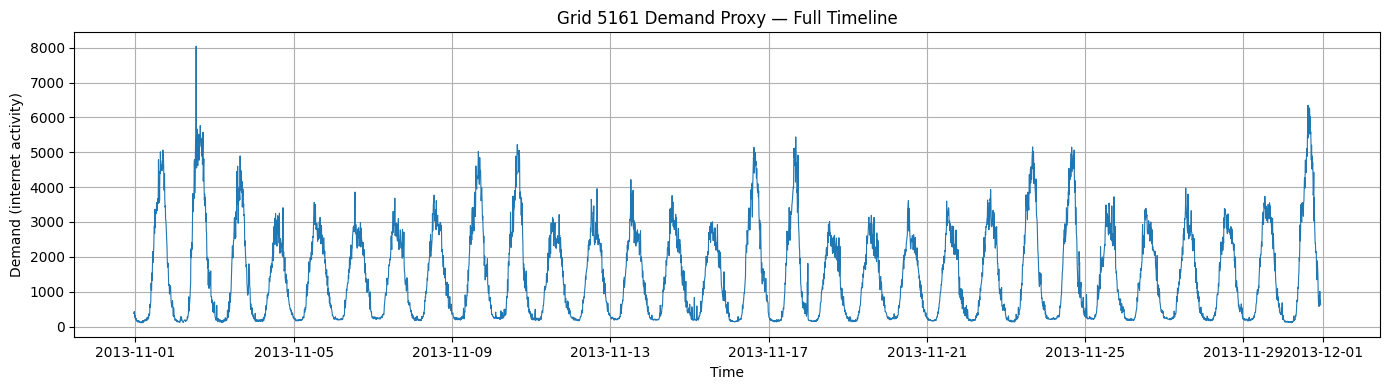

In [177]:
#Full Timeline plot
plt.figure(figsize=(14, 4))
plt.plot(ts_df.index, ts_df["demand"], linewidth=0.8)

plt.title(f"Grid {GRID_ID} Demand Proxy — Full Timeline")
plt.xlabel("Time")
plt.ylabel("Demand (internet activity)")
plt.tight_layout()
plt.show()

In [178]:
# Check the datetime index range
print(ts_df.index.min())
print(ts_df.index.max())

2013-10-31 23:00:00
2013-11-30 22:50:00


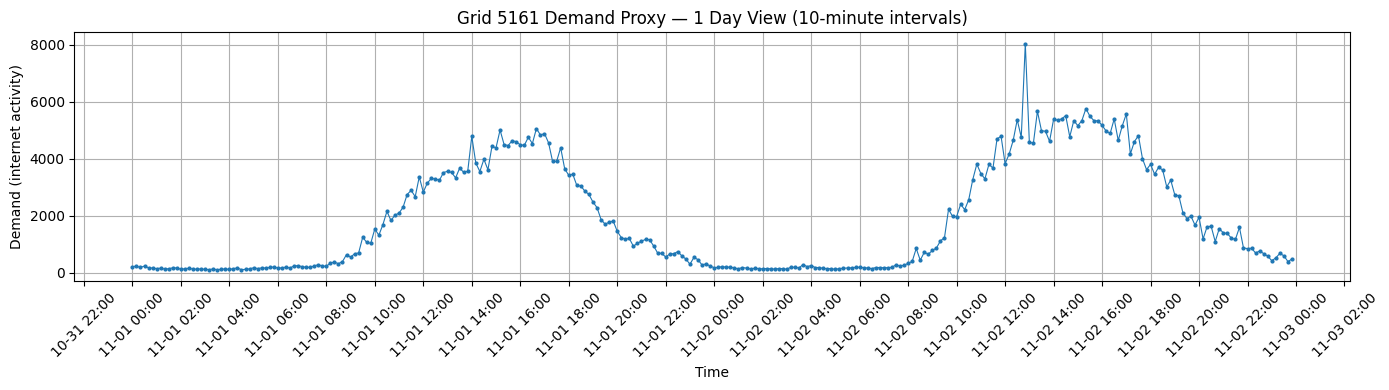

In [179]:
# Short-window plot (1day)
short_start = "2013-11-01"
short_end = "2013-11-02"

ts_short = ts_df.loc[short_start:short_end]

plt.figure(figsize=(14, 4))
plt.plot(ts_short.index, ts_short["demand"], marker="o", markersize=2, linewidth=0.8)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

plt.title(f"Grid {GRID_ID} Demand Proxy — 1 Day View (10-minute intervals)")
plt.xlabel("Time")
plt.ylabel("Demand (internet activity)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

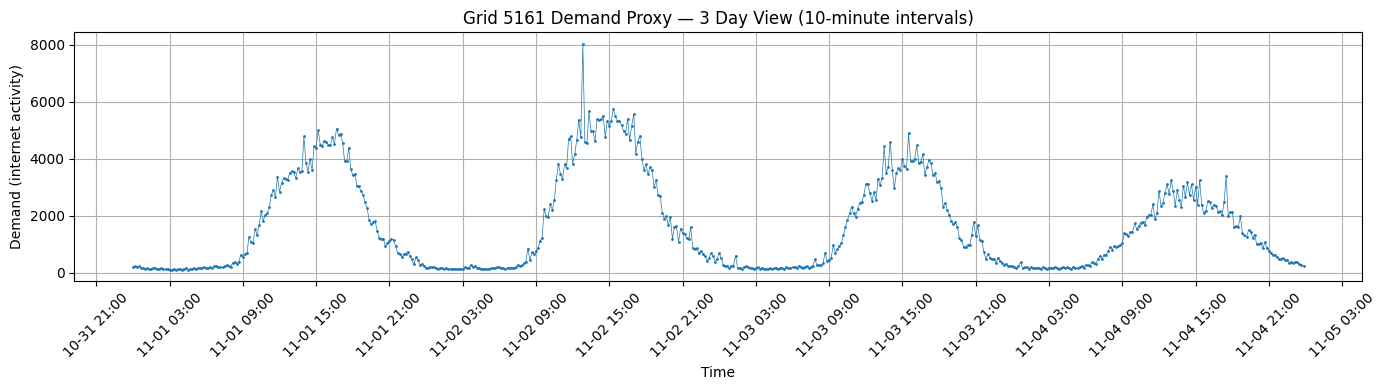

In [180]:
# 3-day window plot
ts_multi = ts_df.loc[multi_start:multi_end]

plt.figure(figsize=(14, 4))
plt.plot(ts_multi.index, ts_multi["demand"], marker="o", markersize=1, linewidth=0.5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M"))

plt.title(f"Grid {GRID_ID} Demand Proxy — 3 Day View (10-minute intervals)")
plt.xlabel("Time")
plt.ylabel("Demand (internet activity)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Section 5 - Define forcasting problem

The predictor uses a sliding window of past traffix demand values to predict the next time step.

Input:
- previous 'k' time steps
  
Output:
- next-step demand

Note: this is an offline forcasting setup that maches the baseline assumption of the project

In [181]:
# Extract raw arrays
values = ts_df["demand"].values.astype(float)
times = ts_df.index.to_numpy()

print("Number of demand values:", len(values))
print("First timestamp:", times[0])
print("Last timestamp:", times[-1])

Number of demand values: 4320
First timestamp: 2013-10-31T23:00:00.000
Last timestamp: 2013-11-30T22:50:00.000


In [182]:
# Define sliding window helper
def make_sliding_windows(values, times, window_size):
    X, y, y_time = [], [], []
    
    for i in range(window_size, len(values)):
        X.append(values[i - window_size:i])
        y.append(values[i])
        y_time.append(times[i])
    
    return np.array(X), np.array(y), np.array(y_time)

In [183]:
# Build the supervised dataset
X, y, y_time = make_sliding_windows(values, times, WINDOW_SIZE)

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("Target timestamp shape:", y_time.shape)

Feature matrix shape: (4308, 12)
Target vector shape: (4308,)
Target timestamp shape: (4308,)


In [184]:
# Indpect one example
example_idx = 0

print("Example input window:")
print(X[example_idx])

print("\nExample target:")
print(y[example_idx])

print("\nTarget timestamp:")
print(y_time[example_idx])

Example input window:
[379.97292919 371.12271251 429.29791133 350.18422353 268.58683213
 326.72634603 212.33277566 231.6425468  187.80206648 234.23739641
 174.65264236 163.1664986 ]

Example target:
146.73100119500438

Target timestamp:
2013-11-01T01:00:00.000


In [185]:
# Inspect one example as a mini table
example_window = pd.DataFrame({
    "datetime": times[:WINDOW_SIZE],
    "demand": X[0]
})

example_window

,datetime,demand
0,2013-10-31 23:00:00,379.972929
1,2013-10-31 23:10:00,371.122713
2,2013-10-31 23:20:00,429.297911
3,2013-10-31 23:30:00,350.184224
4,2013-10-31 23:40:00,268.586832
5,2013-10-31 23:50:00,326.726346
6,2013-11-01 00:00:00,212.332776
7,2013-11-01 00:10:00,231.642547
8,2013-11-01 00:20:00,187.802066
9,2013-11-01 00:30:00,234.237396


### Interpretation

The sliding-window transformation above converts the raw time series into a supervised dataset.

For each prediction example:
- the model sees the previous `WINDOW_SIZE` demand values
- the target is the next demand value in the sequence

This representation is simple, interpretable, and sufficient for building the offline baseline predictor.

## Section 6 - Train/test split

Because this is time-series forcasting, the split must preserve time order.

The training will be done on earlier observation and evaluate on later observations, which siimulates real deployment:
- train offline on historical traffic
- deploy on future traffic

In [186]:
# Split arrays chronologically into train and test sets
split_idx = int(len(X) * TRAIN_RATIO)

X_train = X[:split_idx]
X_test = X[split_idx:]

y_train = y[:split_idx]
y_test = y[split_idx:]

time_train = y_time[:split_idx]
time_test = y_time[split_idx:]

print("Split index:", split_idx)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Split index: 3015
Training samples: 3015
Testing samples: 1293


In [187]:
# Print data ranges
print("Training period:")
print("  Start:", pd.to_datetime(time_train[0]))
print("  End:  ", pd.to_datetime(time_train[-1]))

print("\nTesting period:")
print("  Start:", pd.to_datetime(time_test[0]))
print("  End:  ", pd.to_datetime(time_test[-1]))

Training period:
  Start: 2013-11-01 01:00:00
  End:   2013-11-21 23:20:00

Testing period:
  Start: 2013-11-21 23:30:00
  End:   2013-11-30 22:50:00


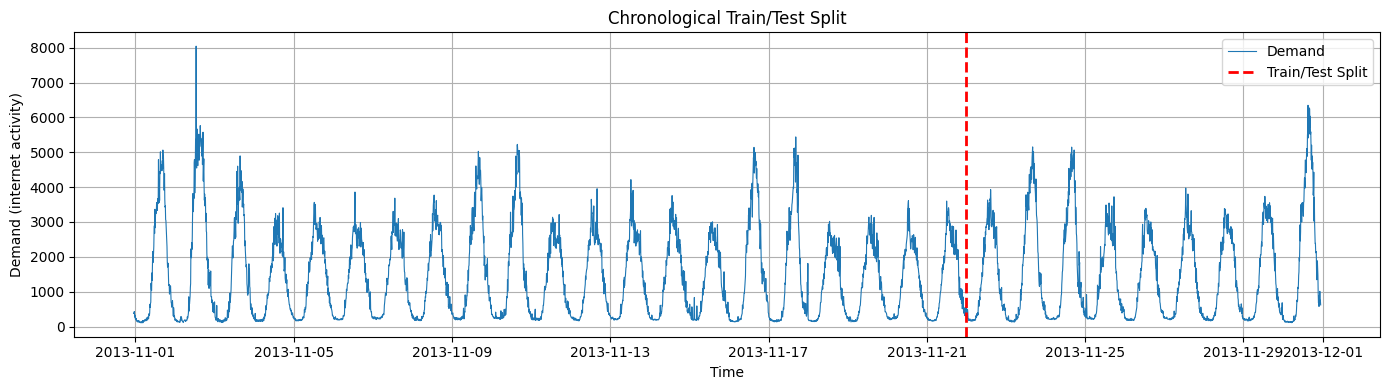

In [188]:
# Plot train/test boundary on full series
split_time = pd.to_datetime(time_test[0])

plt.figure(figsize=(14, 4))
plt.plot(ts_df.index, ts_df["demand"], linewidth=0.8, label="Demand")
plt.axvline(split_time, color="red", linestyle="--", linewidth=2, label="Train/Test Split")

plt.title("Chronological Train/Test Split")
plt.xlabel("Time")
plt.ylabel("Demand (internet activity)")
plt.legend()
plt.tight_layout()
plt.show()

In [189]:
# Summary table
split_summary = pd.DataFrame({
    "subset": ["train", "test"],
    "num_samples": [len(X_train), len(X_test)],
    "start_time": [pd.to_datetime(time_train[0]), pd.to_datetime(time_test[0])],
    "end_time": [pd.to_datetime(time_train[-1]), pd.to_datetime(time_test[-1])]
})

split_summary

,subset,num_samples,start_time,end_time
0,train,3015,2013-11-01 01:00:00,2013-11-21 23:20:00
1,test,1293,2013-11-21 23:30:00,2013-11-30 22:50:00


### Interpretation

The split above creates a realistic offline-training / future-testing setup.

This matches the baseline logic of the project:
- the predictor is trained on historical traffic demand
- the controller is then evaluated on later traffic observations

This chronological separation is important because the project studies forecast-driven control under changing traffic conditions.

## Section 7 - Train baseline predictor

Begin with a simiple forcasting model to establish a reliable simple baseline.
The goal of this project is not to maximize forcasting accuracy at all cost, but to study how threshold adaptation affects downstream network control under traffic drift.

In [190]:
# Initialize and train model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [191]:
# Generate predictions
y_pred_train = baseline_model.predict(X_train)
y_pred_test = baseline_model.predict(X_test)

print("Train prediction shape:", y_pred_train.shape)
print("Test prediction shape:", y_pred_test.shape)

Train prediction shape: (3015,)
Test prediction shape: (1293,)


In [192]:
# Inspect first few predictions
prediction_preview = pd.DataFrame({
    "datetime": pd.to_datetime(time_test[:10]),
    "actual_demand": y_test[:10],
    "predicted_demand": y_pred_test[:10]
})

prediction_preview

,datetime,actual_demand,predicted_demand
0,2013-11-21 23:30:00,447.050104,350.045612
1,2013-11-21 23:40:00,454.750193,405.513370
2,2013-11-21 23:50:00,373.324222,380.491356
3,2013-11-22 00:00:00,598.911032,401.631575
4,2013-11-22 00:10:00,265.223864,531.702938
5,2013-11-22 00:20:00,247.784194,411.303596
6,2013-11-22 00:30:00,231.310643,370.802123
7,2013-11-22 00:40:00,486.640425,301.412196
8,2013-11-22 00:50:00,410.788876,399.857892
9,2013-11-22 01:00:00,219.542861,407.886187


### Interpretation
The model has now been trained on the historical portion of the series and has produced next-step demand predictions for both the training and test periods.

At this stage, I do not yet judge whether the predictions are good or bad. That will be done in the next section using quantitative forecasting metrics and plots.

## Section 8 - Evaluate prediction quality

The evaluation of the offline predictor using standard forcasting metrics:
- MAE
- RMSE
  
These metrics quantify how well the model predicts future traffic demand.

In [193]:
# Compute MAE and RMSE
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

prediction_metrics = pd.DataFrame({
    "split": ["train", "test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse]
})

prediction_metrics

,split,MAE,RMSE
0,train,154.889400,242.414616
1,test,153.095665,231.470349


In [194]:
# Save prediction metrics
prediction_metrics.to_csv(metrics_dir / "baseline_prediction_metrics.csv", index=False)

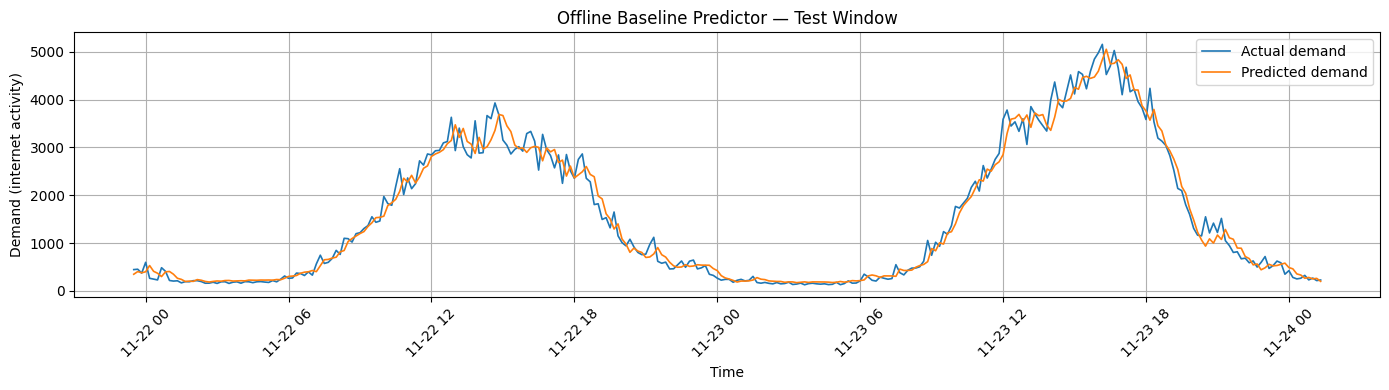

In [195]:
# Plot short test winow: actual vs predicted
plot_n = 300

plot_df = pd.DataFrame({
    "datetime": pd.to_datetime(time_test[:plot_n]),
    "actual_demand": y_test[:plot_n],
    "predicted_demand": y_pred_test[:plot_n]
})

plt.figure(figsize=(14, 4))
plt.plot(plot_df["datetime"], plot_df["actual_demand"], label="Actual demand", linewidth=1.2)
plt.plot(plot_df["datetime"], plot_df["predicted_demand"], label="Predicted demand", linewidth=1.2)

plt.title("Offline Baseline Predictor — Test Window")
plt.xlabel("Time")
plt.ylabel("Demand (internet activity)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [196]:
# Check if predicions go negative
print("Minimum train prediction:", y_pred_train.min())
print("Minimum test prediction:", y_pred_test.min())

Minimum train prediction: -34.89617868320194
Minimum test prediction: 130.40119991128955


In [197]:
# Clip predictions at zero
y_pred_train = np.maximum(y_pred_train, 0)
y_pred_test = np.maximum(y_pred_test, 0)

### Interpretation
The metrics above summarize the offline forecasting quality of the baseline model.

What matters most for the project is not perfect prediction, but whether the predictor is stable and informative enough to support downstream control decisions.

The test-set results are especially important because they represent future unseen traffic, which is the setting in which the controller will operate.

## Section 9 - Define control modes and KPI model

To study forcast-driven control, a simplilfied network model with three operating modes will be defined:
- energy-saving mode
- normal mode
- performance mode

Each mode has:
- a capacity limit
- an energy cost

Using actual traffic demand and the chosen mode, following is computed:
- throughput
- unmet demand / drop
- energy consumption
- energy efficiency

In [198]:
# Define absolute mode parameters
# Use the training-demand distribution to define capacity levels
train_mean = y_train.mean()
train_std = y_train.std()

print("Training demand mean:", train_mean)
print("Training demand std:", train_std)

Training demand mean: 1447.3297106108769
Training demand std: 1273.9107622982829


In [199]:
# Set more capacities and energy costs
MODE_CONFIG_ABS = {
    "energy": {
        "capacity": train_mean * 0.75,
        "energy_cost": 60
    },
    "normal": {
        "capacity": train_mean * 1.00,
        "energy_cost": 90
    },
    "performance": {
        "capacity": train_mean * 1.60,
        "energy_cost": 140
    }
}

MODE_CONFIG_ABS

{'energy': {'capacity': np.float64(1085.4972829581577), 'energy_cost': 60},
 'normal': {'capacity': np.float64(1447.3297106108769), 'energy_cost': 90},
 'performance': {'capacity': np.float64(2315.727536977403),
  'energy_cost': 140}}

In [200]:
# Define KPI computation function
def compute_kpis(actual_load, mode, mode_config):
    capacity = mode_config[mode]["capacity"]
    energy = mode_config[mode]["energy_cost"]

    # Throughput cannot exceed either actual load or available capacity
    throughput = min(actual_load, capacity)

    # Unmet demand / drop is what the mode could not serve
    drop = max(0.0, actual_load - capacity)

    # Energy efficiency = useful throughput per unit energy
    efficiency = throughput / energy

    return {
        "throughput": throughput,
        "drop": drop,
        "energy": energy,
        "efficiency": efficiency
    }

In [201]:
# Quick sanity-check examples
example_loads = [train_mean * 0.7, train_mean, train_mean * 1.4]

sanity_rows = []

for load in example_loads:
    for mode in MODE_CONFIG_ABS.keys():
        kpis = compute_kpis(load, mode, MODE_CONFIG_ABS)
        sanity_rows.append({
            "actual_load": load,
            "mode": mode,
            **kpis
        })

sanity_df = pd.DataFrame(sanity_rows)
sanity_df

,actual_load,mode,throughput,drop,energy,efficiency
0,1013.130797,energy,1013.130797,0.000000,60,16.885513
1,1013.130797,normal,1013.130797,0.000000,90,11.257009
2,1013.130797,performance,1013.130797,0.000000,140,7.236649
3,1447.329711,energy,1085.497283,361.832428,60,18.091621
4,1447.329711,normal,1447.329711,0.000000,90,16.081441
5,1447.329711,performance,1447.329711,0.000000,140,10.338069
6,2026.261595,energy,1085.497283,940.764312,60,18.091621
7,2026.261595,normal,1447.329711,578.931884,90,16.081441
8,2026.261595,performance,2026.261595,0.000000,140,14.473297


### Interpretation
The KPI model above creates the intended tradeoff:

- **energy-saving mode** uses less energy but may leave more demand unmet when traffic is high
- **performance mode** serves more traffic but uses more energy
- **normal mode** provides an intermediate operating point

This is sufficient for the baseline experiment because the project focuses on comparing threshold-control strategies rather than modeling detailed physical-layer behavior.

## Section 10 - Define fixed thresholds

The baseline controller uses two static thresholds chosen from training data:
- low threshold 
- high threshold

These thresholds determine which mode to activate based on predicted traffic demand.
This represents the paper-like offline static decision logic

In [202]:
# Compute thresholds from training data
T_low = np.percentile(y_train, LOW_PERCENTILE)
T_high = np.percentile(y_train, HIGH_PERCENTILE)

print("Low threshold (T_low):", T_low)
print("High threshold (T_high):", T_high)

Low threshold (T_low): 345.18315178692586
High threshold (T_high): 1624.9281774977514


In [203]:
# Put thresholds into a small table
threshold_summary = pd.DataFrame({
    "threshold": ["T_low", "T_high"],
    "percentile": [LOW_PERCENTILE, HIGH_PERCENTILE],
    "value": [T_low, T_high]
})

threshold_summary

,threshold,percentile,value
0,T_low,30,345.183152
1,T_high,60,1624.928177


In [204]:
# Define mode-selection rule
def choose_mode(predicted_load, t_low, t_high):
    if predicted_load < t_low:
        return "energy"
    elif predicted_load > t_high:
        return "performance"
    else:
        return "normal"

In [205]:
example_predictions = [T_low - 1, (T_low + T_high) / 2, T_high + 1]

for pred in example_predictions:
    print(f"Predicted load = {pred:.2f} -> mode = {choose_mode(pred, T_low, T_high)}")

Predicted load = 344.18 -> mode = energy
Predicted load = 985.06 -> mode = normal
Predicted load = 1625.93 -> mode = performance


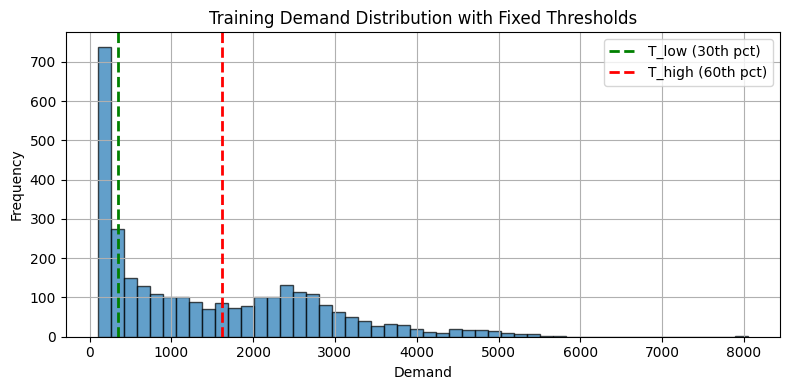

In [206]:
# Plot: Thresholds over training demand histogram
plt.figure(figsize=(8, 4))
plt.hist(y_train, bins=50, alpha=0.7, edgecolor="black")
plt.axvline(T_low, color="green", linestyle="--", linewidth=2, label=f"T_low ({LOW_PERCENTILE}th pct)")
plt.axvline(T_high, color="red", linestyle="--", linewidth=2, label=f"T_high ({HIGH_PERCENTILE}th pct)")

plt.title("Training Demand Distribution with Fixed Thresholds")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

The thresholds above define the baseline controller's decision boundaries.

Because they are computed once from the historical training data and never updated afterward, they represent a **static offline policy**.

This is exactly the type of controller that the adaptive-threshold method will later try to improve upon.

## Section 11 - Running the static controller

At each test time step:
1. predict next-step demand
2. compare the prediction to fixed thresholds
3. choose a mode
4. compute the resulting KPIs

This would produce the baseline against thich the adaptive method will be compared.

In [207]:
# Run controller over test set
baseline_rows = []

for actual_load, predicted_load, timestamp in zip(y_test, y_pred_test, time_test):
    # Choose operating mode using fixed thresholds
    mode = choose_mode(predicted_load, T_low, T_high)
    
    # Compute KPI outcomes using actual demand and chosen mode
    kpis = compute_kpis(actual_load, mode, MODE_CONFIG_ABS)
    
    baseline_rows.append({
        "datetime": pd.to_datetime(timestamp),
        "actual_load": actual_load,
        "predicted_load": predicted_load,
        "mode": mode,
        "T_low": T_low,
        "T_high": T_high,
        "throughput": kpis["throughput"],
        "drop": kpis["drop"],
        "energy": kpis["energy"],
        "efficiency": kpis["efficiency"]
    })

baseline_results = pd.DataFrame(baseline_rows)
baseline_results.head()

,datetime,actual_load,predicted_load,mode,T_low,T_high,throughput,drop,energy,efficiency
0,2013-11-21 23:30:00,447.050104,350.045612,normal,345.183152,1624.928177,447.050104,0.0,90,4.967223
1,2013-11-21 23:40:00,454.750193,405.513370,normal,345.183152,1624.928177,454.750193,0.0,90,5.052780
2,2013-11-21 23:50:00,373.324222,380.491356,normal,345.183152,1624.928177,373.324222,0.0,90,4.148047
3,2013-11-22 00:00:00,598.911032,401.631575,normal,345.183152,1624.928177,598.911032,0.0,90,6.654567
4,2013-11-22 00:10:00,265.223864,531.702938,normal,345.183152,1624.928177,265.223864,0.0,90,2.946932


In [208]:
# Check output shape and columns
print("Baseline results shape:", baseline_results.shape)
print("Columns:", baseline_results.columns.tolist())

Baseline results shape: (1293, 10)
Columns: ['datetime', 'actual_load', 'predicted_load', 'mode', 'T_low', 'T_high', 'throughput', 'drop', 'energy', 'efficiency']


In [209]:
# quick check
print("Unique modes:", baseline_results["mode"].unique())
print("Any missing values?\n", baseline_results.isna().sum())

Unique modes: <ArrowStringArray>
['normal', 'energy', 'performance']
Length: 3, dtype: str
Any missing values?
 datetime          0
actual_load       0
predicted_load    0
mode              0
T_low             0
T_high            0
throughput        0
drop              0
energy            0
efficiency        0
dtype: int64


In [210]:
# Preview a few rows
baseline_results[["datetime", "actual_load", "predicted_load", "mode", "throughput", "drop", "energy", "efficiency"]].head(10)

,datetime,actual_load,predicted_load,mode,throughput,drop,energy,efficiency
0,2013-11-21 23:30:00,447.050104,350.045612,normal,447.050104,0.0,90,4.967223
1,2013-11-21 23:40:00,454.750193,405.513370,normal,454.750193,0.0,90,5.052780
2,2013-11-21 23:50:00,373.324222,380.491356,normal,373.324222,0.0,90,4.148047
3,2013-11-22 00:00:00,598.911032,401.631575,normal,598.911032,0.0,90,6.654567
4,2013-11-22 00:10:00,265.223864,531.702938,normal,265.223864,0.0,90,2.946932
5,2013-11-22 00:20:00,247.784194,411.303596,normal,247.784194,0.0,90,2.753158
6,2013-11-22 00:30:00,231.310643,370.802123,normal,231.310643,0.0,90,2.570118
7,2013-11-22 00:40:00,486.640425,301.412196,energy,486.640425,0.0,60,8.110674
8,2013-11-22 00:50:00,410.788876,399.857892,normal,410.788876,0.0,90,4.564321
9,2013-11-22 01:00:00,219.542861,407.886187,normal,219.542861,0.0,90,2.439365


### Interpretation

The table above contains the complete static-baseline controller output on the test period.

For each test timestamp, it records:
- the actual demand
- the predicted demand
- the chosen mode
- the resulting throughput
- unmet demand / drop
- energy consumption
- energy efficiency

This table is the main output of the static baseline and will be summarized in the next section.

## Section 12 - Baseline Results

The baseline controller will be summarized using:
- average throughput
- average energy consumption
- average energy efficiency
- total unment demand
- mode usage frequency

These reaults provide the fifixed-threshold reference point for the adaptive controller.

In [211]:
# KPI Summary table
baseline_summary = pd.DataFrame({
    "metric": [
        "avg_throughput",
        "total_drop",
        "drop_rate",
        "avg_energy",
        "avg_efficiency"
    ],
    "value": [
        baseline_results["throughput"].mean(),
        baseline_results["drop"].sum(),
        baseline_results["drop"].sum() / baseline_results["actual_load"].sum(),
        baseline_results["energy"].mean(),
        baseline_results["efficiency"].mean()
    ]
})

baseline_summary

,metric,value
0,avg_throughput,1201.397499
1,total_drop,408751.948033
2,drop_rate,0.208317
3,avg_energy,101.322506
4,avg_efficiency,10.185520


In [212]:
# Mode usage table
mode_usage = (
    baseline_results["mode"]
    .value_counts(normalize=True)
    .rename("fraction")
    .reset_index()
)

mode_usage.columns = ["mode", "fraction"]
mode_usage

,mode,fraction
0,performance,0.396752
1,normal,0.319412
2,energy,0.283836


In [213]:
# Save summary tables
baseline_summary.to_csv(metrics_dir / "baseline_controller_summary.csv", index=False)
mode_usage.to_csv(metrics_dir / "baseline_mode_usage.csv", index=False)

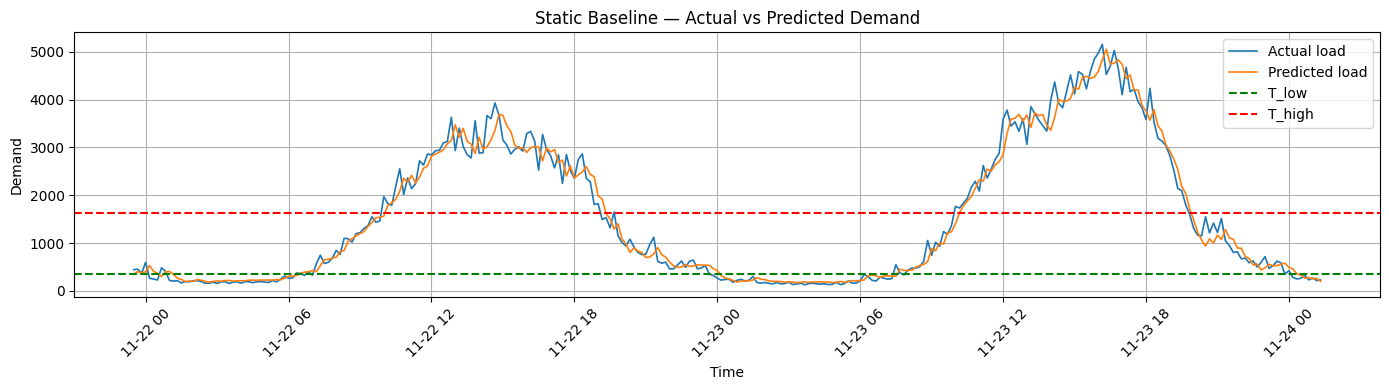

In [214]:
# Plot actual vs predicted with thresholds (short window)
plot_n = 300
plot_df = baseline_results.iloc[:plot_n].copy()

plt.figure(figsize=(14, 4))
plt.plot(plot_df["datetime"], plot_df["actual_load"], label="Actual load", linewidth=1.2)
plt.plot(plot_df["datetime"], plot_df["predicted_load"], label="Predicted load", linewidth=1.2)
plt.axhline(T_low, color="green", linestyle="--", linewidth=1.5, label="T_low")
plt.axhline(T_high, color="red", linestyle="--", linewidth=1.5, label="T_high")

plt.title("Static Baseline — Actual vs Predicted Demand")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

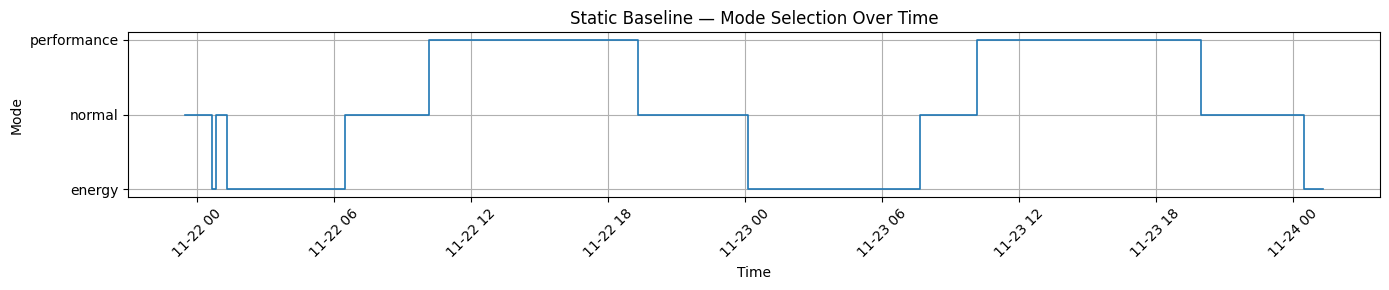

In [215]:
# Plot mode over time
mode_to_num = {"energy": 0, "normal": 1, "performance": 2}

plt.figure(figsize=(14, 3))
plt.step(
    plot_df["datetime"],
    plot_df["mode"].map(mode_to_num),
    where="post",
    linewidth=1.2
)

plt.yticks([0, 1, 2], ["energy", "normal", "performance"])
plt.title("Static Baseline — Mode Selection Over Time")
plt.xlabel("Time")
plt.ylabel("Mode")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

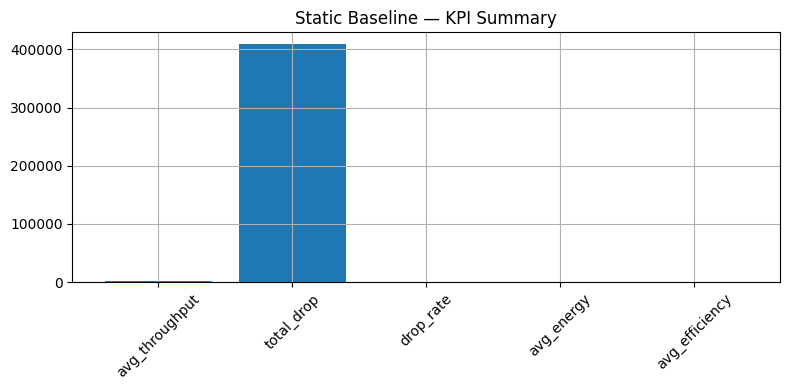

In [216]:
# KPI summary bar chart
plt.figure(figsize=(8, 4))
plt.bar(baseline_summary["metric"], baseline_summary["value"])
plt.title("Static Baseline — KPI Summary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

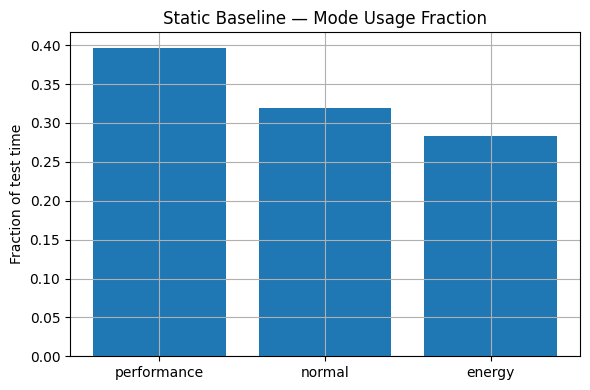

In [217]:
# Mode usage bar chart
plt.figure(figsize=(6, 4))
plt.bar(mode_usage["mode"], mode_usage["fraction"])
plt.title("Static Baseline — Mode Usage Fraction")
plt.ylabel("Fraction of test time")
plt.tight_layout()
plt.show()

### Interpretation

The baseline results above summarize how the fixed-threshold controller behaves on the test period.

The key outputs are:
- whether throughput remains high enough
- how much unmet demand accumulates
- how much energy the controller uses
- how often the controller stays in energy-saving, normal, or performance mode

These results will serve as the reference point for evaluating whether KPI-feedback-based threshold adaptation improves the throughput–energy tradeoff.

## Section 13 - Save artifacts for next notebook

To keep the workfolw modular, the following will be saved for the next notebook:
- processed test sequence
- offline predictions
- baseline thresholds
- baseline KPI results

In [218]:
# Save test-period actual and rpedicted demand
test_predictions = pd.DataFrame({
    "datetime": pd.to_datetime(time_test),
    "actual_load": y_test,
    "predicted_load": y_pred_test
})

test_predictions.to_csv(metrics_dir / "test_predictions_for_adaptive.csv", index=False)
test_predictions.head()

,datetime,actual_load,predicted_load
0,2013-11-21 23:30:00,447.050104,350.045612
1,2013-11-21 23:40:00,454.750193,405.513370
2,2013-11-21 23:50:00,373.324222,380.491356
3,2013-11-22 00:00:00,598.911032,401.631575
4,2013-11-22 00:10:00,265.223864,531.702938


In [219]:
# Save thresholds
thresholds_df = pd.DataFrame({
    "T_low": [T_low],
    "T_high": [T_high],
    "low_percentile": [LOW_PERCENTILE],
    "high_percentile": [HIGH_PERCENTILE]
})

thresholds_df.to_csv(metrics_dir / "baseline_thresholds.csv", index=False)
thresholds_df

,T_low,T_high,low_percentile,high_percentile
0,345.183152,1624.928177,30,60


In [220]:
# Save full baseline controlelr time series
baseline_results.to_csv(metrics_dir / "baseline_results_timeseries.csv", index=False)

In [221]:
# Save summary tables again explicitly
baseline_summary.to_csv(metrics_dir / "baseline_controller_summary.csv", index=False)
mode_usage.to_csv(metrics_dir / "baseline_mode_usage.csv", index=False)

In [222]:
#Confirmation of saved files
saved_files = [
    metrics_dir / "test_predictions_for_adaptive.csv",
    metrics_dir / "baseline_thresholds.csv",
    metrics_dir / "baseline_results_timeseries.csv",
    metrics_dir / "baseline_controller_summary.csv",
    metrics_dir / "baseline_mode_usage.csv",
]

for f in saved_files:
    print(f.name, "->", f.exists())

test_predictions_for_adaptive.csv -> True
baseline_thresholds.csv -> True
baseline_results_timeseries.csv -> True
baseline_controller_summary.csv -> True
baseline_mode_usage.csv -> True


## 14. Conclusion

This notebook established the offline static baseline for the project.

Completed steps:
- loaded and validated the selected one-grid demand time series
- defined a next-step forecasting problem
- trained an offline baseline predictor
- evaluated prediction quality
- defined a fixed-threshold controller
- simulated baseline control decisions
- summarized baseline KPI outcomes
- saved artifacts for later comparison

Next step:
- implement KPI-feedback-based threshold adaptation
- compare the adaptive controller against this fixed-threshold baseline